<a href="https://colab.research.google.com/github/Sanjna0301/WaitlistWizard/blob/main/bike_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [55]:
df = pd.read_csv('/indian_bikes_dataset_1000.csv')

print(df.head())
print(df.info())
print(df.isnull().sum())

           brand             model   cc  segment  year speedometer_type  \
0          Honda        Hornet 2.0  184      mid  2020          Digital   
1          Bajaj       Pulsar N250  249      mid  2024          Digital   
2           Hero     Splendor Plus   97   budget  2020           Analog   
3  Royal Enfield  Thunderbird 350X  346  premium  2025     Semi-Digital   
4  Royal Enfield         Scram 411  411  premium  2023     Semi-Digital   

   top_speed_kmh  mileage_kmpl  fuel_tank_liters  factory_price_inr  \
0            137          43.8              10.1             100781   
1            157          33.2              14.9             123438   
2             95          64.2               8.7              60156   
3            152          29.1              17.3             146875   
4            165          23.4              14.9             166412   

   gst_rate_pct  gst_amount_inr  ex_showroom_inr  on_road_price_inr  \
0          28.0           28219           129000   

In [56]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [57]:
df = pd.get_dummies(df, drop_first=True)

In [58]:

print(df.head())

    cc  year  top_speed_kmh  mileage_kmpl  fuel_tank_liters  \
0  184  2020            137          43.8              10.1   
1  249  2024            157          33.2              14.9   
2   97  2020             95          64.2               8.7   
3  346  2025            152          29.1              17.3   
4  411  2023            165          23.4              14.9   

   factory_price_inr  gst_rate_pct  gst_amount_inr  ex_showroom_inr  \
0             100781          28.0           28219           129000   
1             123438          28.0           34562           158000   
2              60156          28.0           16844            77000   
3             146875          28.0           41125           188000   
4             166412          31.0           51588           218000   

   on_road_price_inr  ...  segment_premium  speedometer_type_Digital  \
0             147604  ...            False                      True   
1             185890  ...            False        

In [59]:
#Features and Target
X = df.drop('on_road_price_inr', axis=1)
y = df['on_road_price_inr']

In [60]:
#split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [61]:
print(X_train.shape)
print(X_test.shape)

(800, 100)
(200, 100)


In [62]:
#train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [63]:
#predictions
predictions = model.predict(X_test)

print(predictions[:5])

[ 99408.8  188758.92 210804.57 222238.88 337788.21]


In [64]:
#evaluate Model
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("MAE:", mae)
print("R2 Score:", r2)

MAE: 2408.89595
R2 Score: 0.9979987280420877


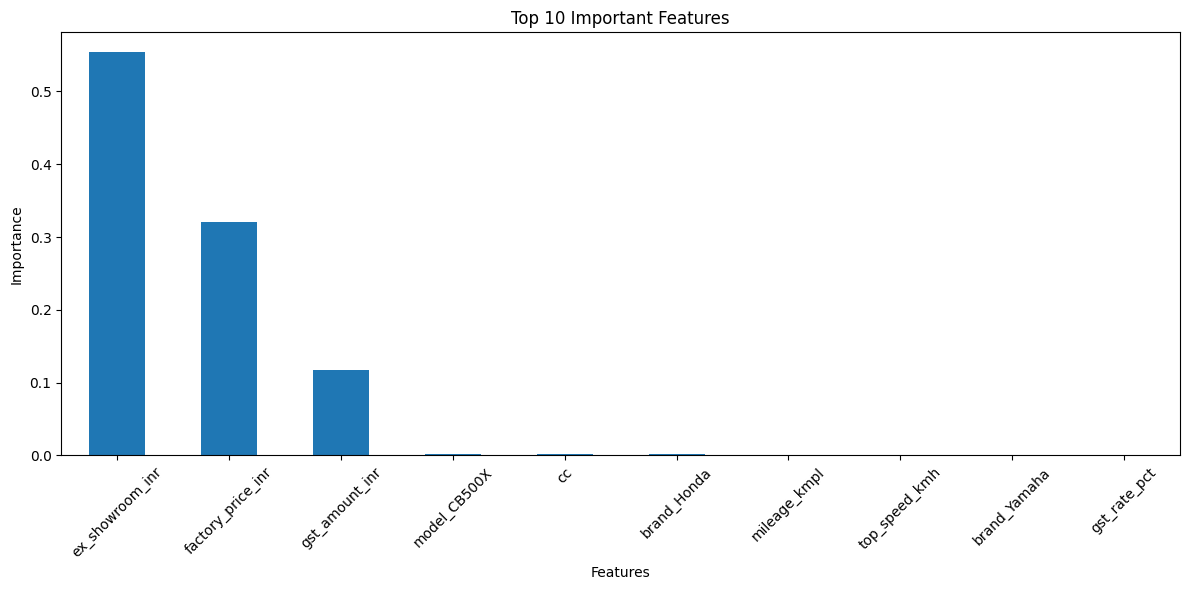

In [65]:
#Graph
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(12,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
# Predict Sample Bike Price
sample_bike = X.iloc[[0]]
predicted_price = model.predict(sample_bike)

print("Predicted Price:", predicted_price[0])

Predicted Price: 148024.07
